# El chorro del Atlántico no se hizo más fuerte por arriba. Se hizo más fuerte por abajo.

El 26 de diciembre de 1836 la corriente en chorro que gobierna el invierno europeo tocó su fondo: el día más flojo de un registro diario que arranca en 1725. Lo sabemos porque cuatro barómetros —Londres, Padua, Uppsala y Berlín— llevan tres siglos anotando la presión todos los días.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** Brönnimann et al. (2026). *A strengthening yet less extreme Atlantic–European jet during winter*. **Nature Geoscience**

**DOI:** [10.1038/s41561-026-02069-z](https://doi.org/10.1038/s41561-026-02069-z)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-09-10-corriente-chorro-atlantico-europea/notebook.ipynb)

**Video:** [Ver en YouTube](https://youtube.com/shorts/t4VR1ABKlJ0)

## Qué es esto que vamos a medir

La corriente en chorro del Atlántico es el río de viento a diez kilómetros de altura que decide si a Europa le toca un invierno de temporales o uno de niebla y quietud. Cuando corre fuerte y recto, mete borrascas atlánticas por el norte. Cuando se afloja o se tuerce, deja entrar el aire frío continental.

Nadie tenía un satélite en 1725. Pero sí había barómetros. El equipo aprovechó que la diferencia de presión entre estaciones europeas es la huella en superficie de lo que hace el chorro arriba, y con cuatro series largas —Londres, Padua, Uppsala y Berlín— reconstruyó tres índices diarios: **fuerza**, **inclinación** y **latitud** del chorro, día a día, de 1725 a 2024.

Nosotros trabajamos con la **temporada fría** (noviembre a abril), que es donde el paper concentra sus titulares: 54.373 días repartidos en diez períodos de 30 años.

Una advertencia antes de arrancar: estos índices son la **huella en superficie** del chorro, no una medición del viento en altura. El propio paper lo dice — *"our diagnostics describe the surface imprint"*.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
# Base de normalización del paper: SD de los índices DIARIOS de
# temporada fría en 1851-1950. Las columnas del depósito NO son
# z-scores unitarios (la SD de `fuerza` en temporada fría es 1,499),
# así que dividir por
# estas constantes es lo que pone nuestras cifras en las mismas
# unidades que los titulares del artículo.
SD_FUERZA = 1.52          # SD diaria de fuerza, temporada fría 1851-1950
SD_INCLINACION = 0.8989   # ídem para inclinación
SD_LATITUD = 1.0059       # ídem para latitud

PERIODO_PREINDUSTRIAL = '1725-1754'   # el primer bloque de 30 años
PERIODO_ACTUAL = '1995-2024'          # el último
UMBRAL_EXTREMO = 2.0                  # días fuera de ±2 SD

FUENTE = ('Fuente: Brönnimann et al. (2026), Nature Geoscience | '
          'Datos: Figshare 10.6084/m9.figshare.29445245')
COLOR_DATOS = '#2563EB'        # azul CaM
COLOR_ALERTA = '#DC2626'       # rojo
COLOR_SECUNDARIO = '#059669'   # verde
COLOR_REFERENCIA = '#D97706'   # ámbar
COLOR_CONTEXTO = '#BBBBBB'     # gris

# ── Setup ──────────────────────────────────────────────────────
import os
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

BASE = ('https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/'
        'papers/2026-09-10-corriente-chorro-atlantico-europea')

# Estilo CaM (local → fallback a GitHub raw)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

os.makedirs('datos', exist_ok=True)
os.makedirs('figuras', exist_ok=True)


def cargar(nombre):
    ruta = f'datos/{nombre}'
    if not os.path.exists(ruta):
        urllib.request.urlretrieve(f'{BASE}/datos/{nombre}', ruta)
    return pd.read_csv(ruta)


# ── Carga ──────────────────────────────────────────────────────
diario = cargar('indices_diarios_temporada_fria.csv')
anual = cargar('serie_anual_temporada_fria.csv')
distrib = cargar('distribucion_por_periodo.csv')
extremos = cargar('extremos_por_periodo.csv')

# Todo a unidades de SD del paper
for df in (diario, anual):
    df['fuerza_sd'] = df['fuerza'] / SD_FUERZA
    df['inclinacion_sd'] = df['inclinacion'] / SD_INCLINACION
    df['latitud_sd'] = df['latitud'] / SD_LATITUD

for col in ['p2', 'p25', 'mediana', 'p75', 'p98', 'media', 'std']:
    distrib[f'fuerza_{col}_sd'] = distrib[f'fuerza_{col}'] / SD_FUERZA
    distrib[f'latitud_{col}_sd'] = distrib[f'latitud_{col}'] / SD_LATITUD

print(f'Días de temporada fría (nov-abr): {len(diario):,}'.replace(',', '.'))
print(f'Años de registro: {len(anual)}  ({anual.anio.min()}-{anual.anio.max()})')
print(f'Períodos de 30 años: {distrib.periodo.nunique()}')
print(f'Valores faltantes: {int(diario[["fuerza", "inclinacion", "latitud"]].isna().sum().sum())}')
print()
print('Control de la base de normalización — SD de los índices DIARIOS')
print('de temporada fría en 1851-1950 (la que usa el paper):')
base = diario[(diario.anio >= 1851) & (diario.anio <= 1950)]
for nombre, col, sd in [('fuerza', 'fuerza', SD_FUERZA),
                        ('inclinación', 'inclinacion', SD_INCLINACION),
                        ('latitud', 'latitud', SD_LATITUD)]:
    print(f'  {nombre:<12} calculada = {base[col].std(ddof=1):.4f}   '
          f'usada = {sd}')
print(f'  (n = {len(base):,} días)'.replace(',', '.'))

Días de temporada fría (nov-abr): 54.373
Años de registro: 300  (1725-2024)
Períodos de 30 años: 10
Valores faltantes: 0

Control de la base de normalización — SD de los índices DIARIOS
de temporada fría en 1851-1950 (la que usa el paper):
  fuerza       calculada = 1.5200   usada = 1.52
  inclinación  calculada = 0.8988   usada = 0.8989
  latitud      calculada = 1.0059   usada = 1.0059
  (n = 18.124 días)


Aquí están los 300 años.

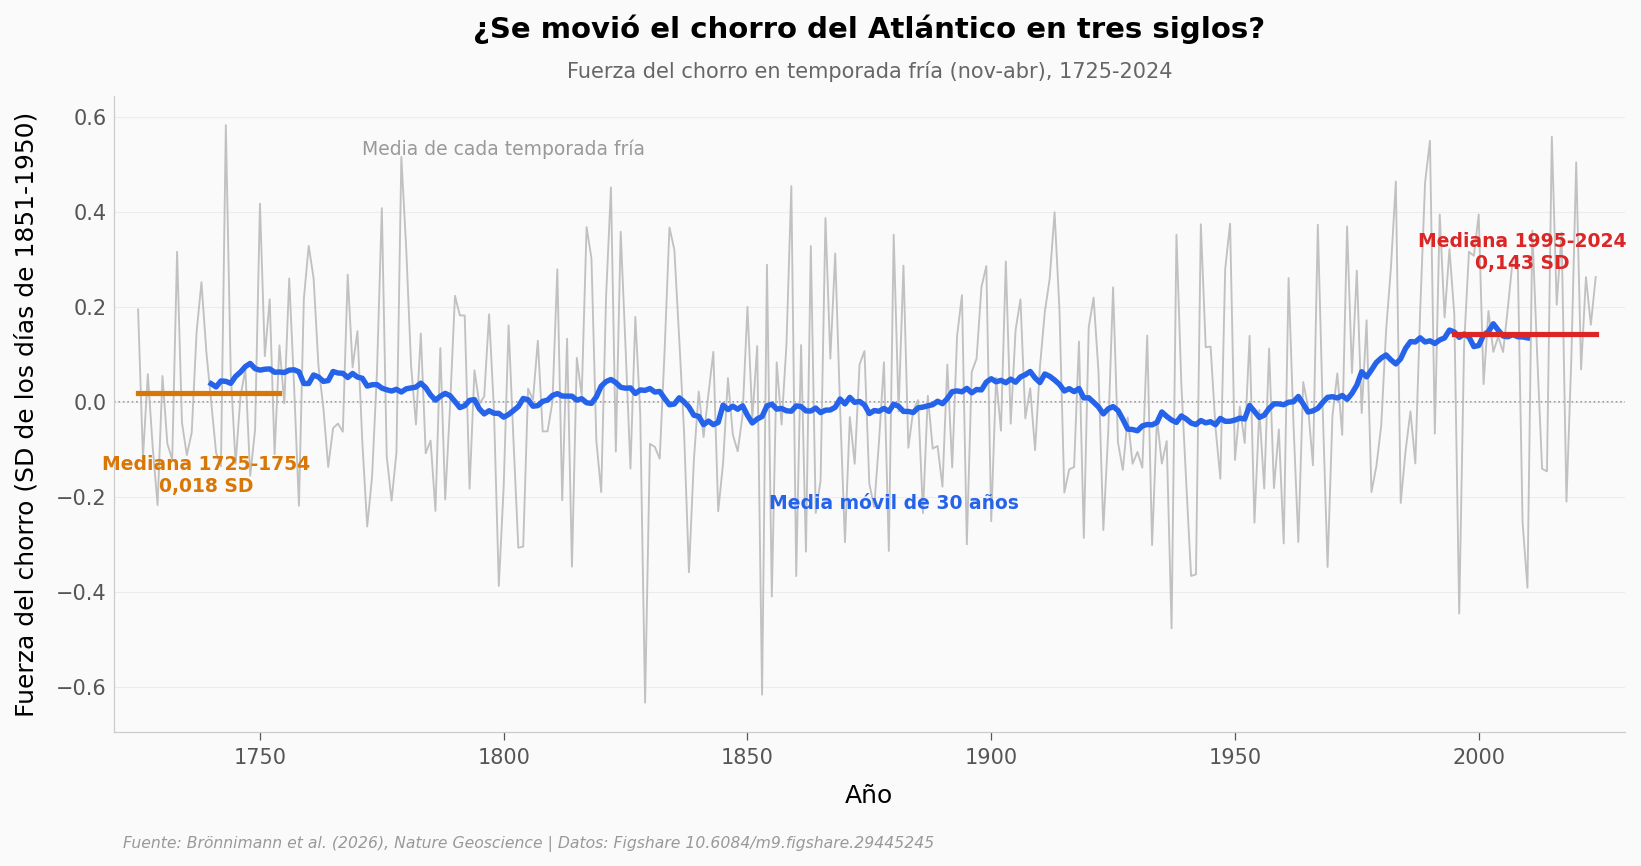

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

x = anual['anio'].values
y = anual['fuerza_sd'].values

# Serie anual cruda al fondo
ax.plot(x, y, color=COLOR_CONTEXTO, linewidth=0.9, alpha=0.9, zorder=2)
ax.axhline(0, color='#888888', linewidth=0.8, linestyle=':', zorder=1)

# Media móvil de 30 años — la escala de los períodos del paper
suavizado = pd.Series(y).rolling(30, center=True, min_periods=30).mean()
ax.plot(x, suavizado, color=COLOR_DATOS, linewidth=2.6, zorder=5)

# Las dos medianas que compara el paper
med_pre = distrib.loc[distrib.periodo == PERIODO_PREINDUSTRIAL,
                      'fuerza_mediana_sd'].iloc[0]
med_act = distrib.loc[distrib.periodo == PERIODO_ACTUAL,
                      'fuerza_mediana_sd'].iloc[0]
ax.plot([1725, 1754], [med_pre, med_pre], color=COLOR_REFERENCIA,
        linewidth=2.5, zorder=6)
ax.plot([1995, 2024], [med_act, med_act], color=COLOR_ALERTA,
        linewidth=2.5, zorder=6)

ax.text(1739, med_pre - 0.13, f'Mediana {PERIODO_PREINDUSTRIAL}\n{med_pre:.3f} SD'.replace('.', ','),
        fontsize=9, color=COLOR_REFERENCIA, fontweight='bold', ha='center', va='top')
ax.text(2009, med_act + 0.13, f'Mediana {PERIODO_ACTUAL}\n{med_act:.3f} SD'.replace('.', ','),
        fontsize=9, color=COLOR_ALERTA, fontweight='bold', ha='center', va='bottom')
ax.text(1880, suavizado[155] - 0.22, 'Media móvil de 30 años', fontsize=9,
        color=COLOR_DATOS, fontweight='bold', ha='center')
ax.text(1800, 0.52, 'Media de cada temporada fría', fontsize=9,
        color='#999999', ha='center')

ax.set_title('¿Se movió el chorro del Atlántico en tres siglos?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Fuerza del chorro en temporada fría (nov-abr), 1725-2024',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Año')
ax.set_ylabel('Fuerza del chorro (SD de los días de 1851-1950)')
ax.set_xlim(1720, 2030)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/hero_serie_300_anios.png', dpi=200, bbox_inches='tight')
plt.show()

## Lo que cuesta ver

Tres siglos de altibajos y ninguna rampa. Si le pedimos a los 300 años una tendencia lineal, sale de **0,022 SD por siglo y no es significativa** (p = 0,13): el movimiento no es una pendiente sostenida desde 1725.

Lo que sí se despega es el final. La mediana de la temporada fría pasa de **0,018 SD** en 1725-1754 a **0,143 SD** en 1995-2024: una subida de **0,125 SD** que reproduce el 0,13 que reporta el paper. Los últimos 60 años (1965-2024) quedan **0,114 SD** de mediana por encima de todo lo anterior.

Y aquí conviene frenar, porque 0,125 SD suena a poco y lo es: entre el primer período y el último, el tamaño del efecto es **Cohen's d = 0,10**, que en cualquier manual es *pequeño*. Con 10.875 días la prueba de Mann-Whitney da p < 0,0001, pero significativo y grande no son la misma palabra. El interés de este resultado no está en el tamaño del salto, sino en **de dónde salió**.

## La media es mala consejera

Una mediana que sube admite dos historias muy distintas. Puede que la distribución entera se haya corrido a la derecha —todos los días un poco más ventosos— o puede que se haya deformado por un solo lado.

Miremos los percentiles de los diez períodos, no el promedio.

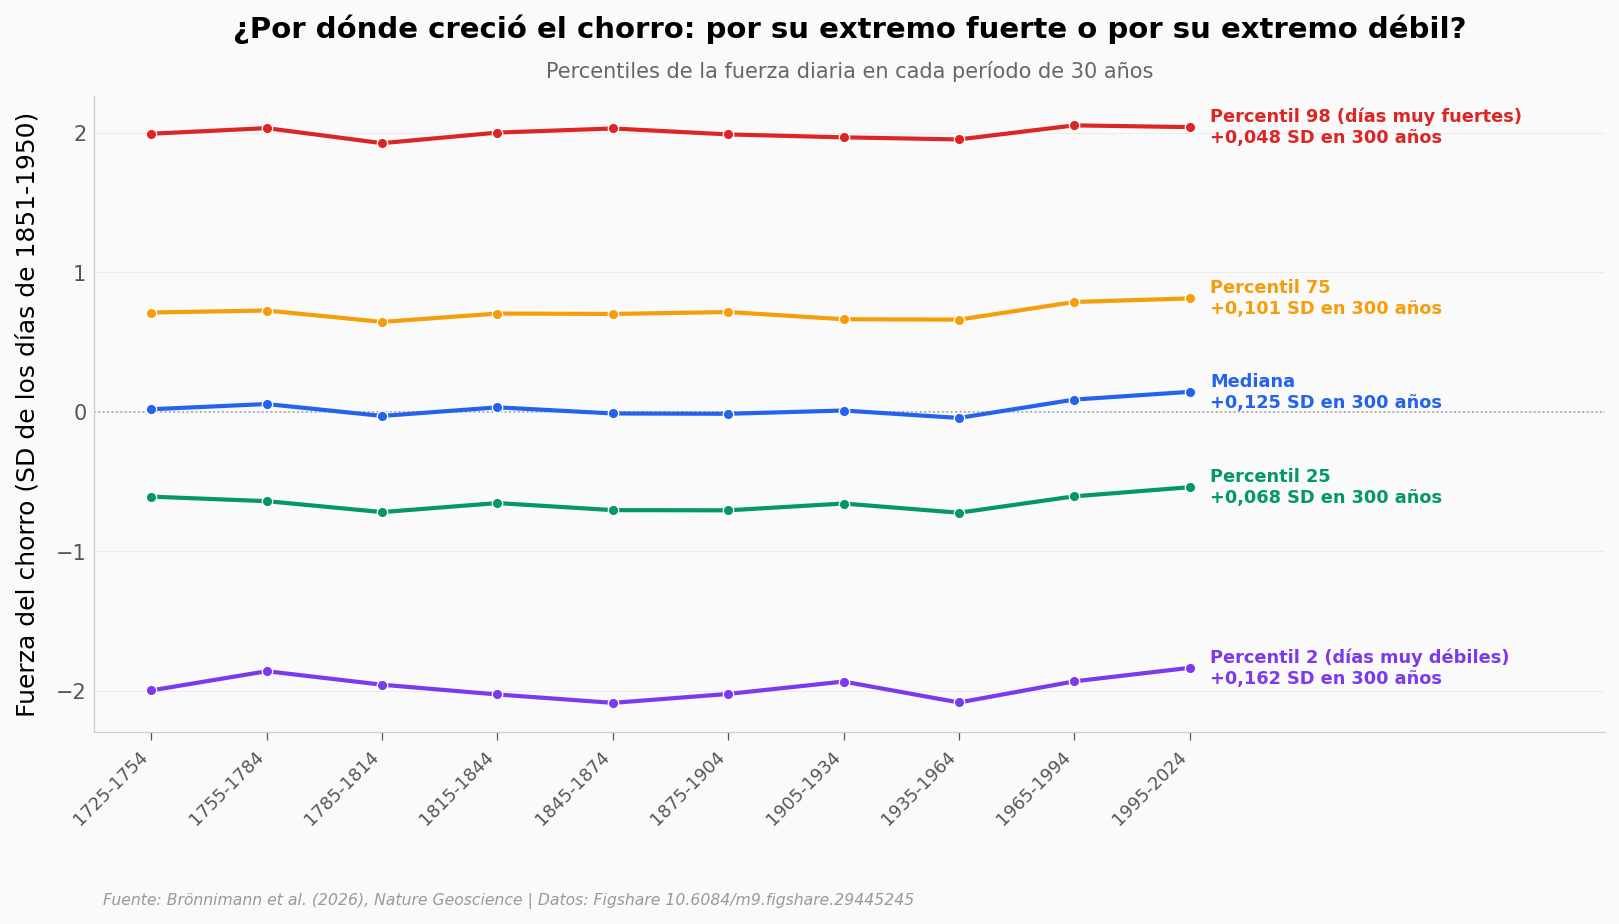

Fuerza del chorro por percentil — primer período vs último (en SD)
                             1725-1754   1995-2024    cambio
Percentil 98                     1.992       2.040    +0.048
Percentil 75                     0.711       0.812    +0.101
Mediana                          0.018       0.143    +0.125
Percentil 25                    -0.608      -0.541    +0.068
Percentil 2                     -1.997      -1.835    +0.162


In [3]:
fig, ax = plt.subplots(figsize=(13, 5.5))

per = distrib['periodo'].tolist()
pos = np.arange(len(per))

series = [
    ('fuerza_p98_sd', 'Percentil 98 (días muy fuertes)', COLOR_ALERTA),
    ('fuerza_p75_sd', 'Percentil 75', '#F59E0B'),
    ('fuerza_mediana_sd', 'Mediana', COLOR_DATOS),
    ('fuerza_p25_sd', 'Percentil 25', COLOR_SECUNDARIO),
    ('fuerza_p2_sd', 'Percentil 2 (días muy débiles)', '#7C3AED'),
]
for col, etiqueta, color in series:
    ax.plot(pos, distrib[col], marker='o', markersize=5, linewidth=2,
            color=color, markeredgecolor='white', markeredgewidth=0.6, zorder=5)
    delta = distrib[col].iloc[-1] - distrib[col].iloc[0]
    ax.text(pos[-1] + 0.18, distrib[col].iloc[-1],
            f'{etiqueta}\n{delta:+.3f} SD en 300 años'.replace('.', ','),
            fontsize=8.5, color=color, fontweight='bold', va='center')

ax.set_title('¿Por dónde creció el chorro: por su extremo fuerte o por su extremo débil?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Percentiles de la fuerza diaria en cada período de 30 años',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xticks(pos)
ax.set_xticklabels(per, rotation=45, ha='right', fontsize=8.5)
ax.set_ylabel('Fuerza del chorro (SD de los días de 1851-1950)')
ax.set_xlim(-0.5, len(per) + 2.6)
ax.axhline(0, color='#888888', linewidth=0.8, linestyle=':', zorder=1)

fig.text(0.13, -0.10, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/percentiles_por_periodo.png', dpi=200, bbox_inches='tight')
plt.show()

print('Fuerza del chorro por percentil — primer período vs último (en SD)')
print(f'{"":<26}{PERIODO_PREINDUSTRIAL:>12}{PERIODO_ACTUAL:>12}{"cambio":>10}')
for col, etiqueta, _ in series:
    a, b = distrib[col].iloc[0], distrib[col].iloc[-1]
    print(f'{etiqueta.split(" (")[0]:<26}{a:>12.3f}{b:>12.3f}{b - a:>+10.3f}')

## El chorro no ganó techo: perdió suelo

Ahí está el golpe. El percentil 2 —el borde de los días más flojos— subió **0,162 SD**, más que la mediana. El percentil 98 —el borde de los días más ventosos— subió apenas **0,048 SD**, casi nada.

Dicho de otro modo: el techo del chorro casi no se movió en 300 años. Lo que ya casi no hace es **pararse**.

Si eso es cierto, tiene que verse en el conteo de días excepcionales. Contemos cuántos días de cada período caen fuera de ±2 SD, separando las dos colas.

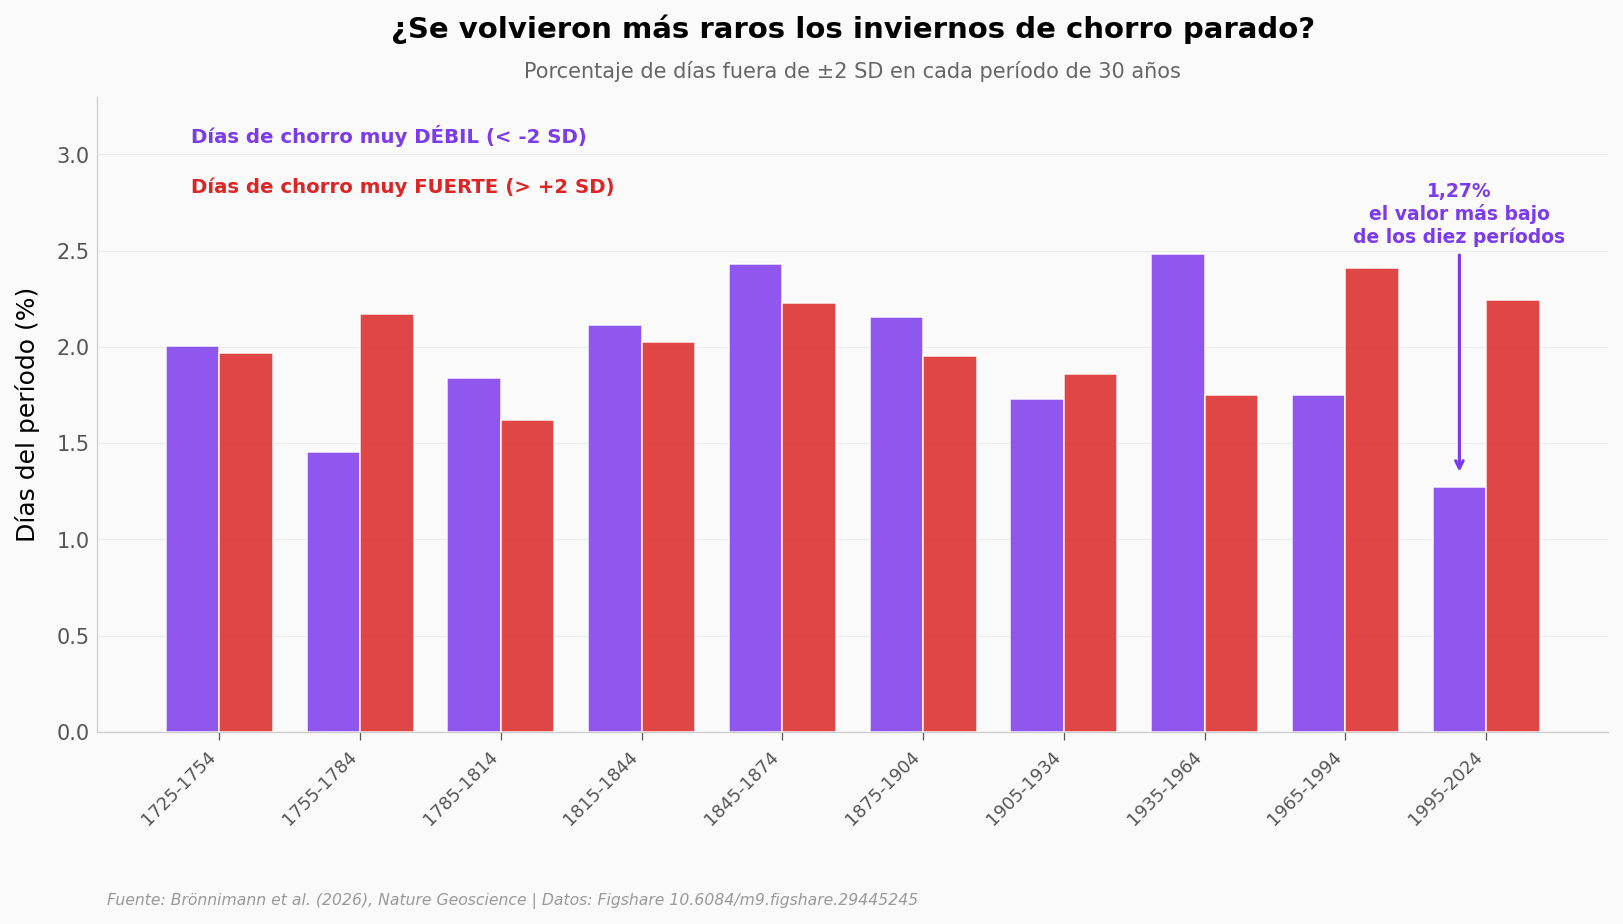

Cola débil  · 1725-1754: 2.00%  →  1995-2024: 1.27%
Cola fuerte · 1725-1754: 1.97%  →  1995-2024: 2.24%
  ...pero el período anterior (1965-1994) tuvo MÁS días fuertes: 2.41%


In [4]:
fig, ax = plt.subplots(figsize=(13, 5.5))

pos = np.arange(len(extremos))
ancho = 0.38

ax.bar(pos - ancho / 2, extremos['fuerza_pct_bajo_-2sd'], width=ancho,
       color='#7C3AED', alpha=0.85, edgecolor='white', linewidth=0.8, zorder=5)
ax.bar(pos + ancho / 2, extremos['fuerza_pct_sobre_+2sd'], width=ancho,
       color=COLOR_ALERTA, alpha=0.85, edgecolor='white', linewidth=0.8, zorder=5)

# Etiquetas apiladas arriba a la izquierda: ahí no hay barras que tapar
ax.text(-0.2, 3.06, 'Días de chorro muy DÉBIL (< -2 SD)', fontsize=9.5,
        color='#7C3AED', fontweight='bold')
ax.text(-0.2, 2.80, 'Días de chorro muy FUERTE (> +2 SD)', fontsize=9.5,
        color=COLOR_ALERTA, fontweight='bold')

# Señalar el mínimo histórico de la cola débil — flecha vertical sobre
# la propia barra, que es la única columna de aire libre de la derecha
i_min = int(extremos['fuerza_pct_bajo_-2sd'].idxmin())
v_min = extremos['fuerza_pct_bajo_-2sd'].iloc[i_min]
ax.annotate(f'{v_min:.2f}%'.replace('.', ',')
            + '\nel valor más bajo\nde los diez períodos',
            xy=(i_min - ancho / 2, v_min + 0.06),
            xytext=(i_min - ancho / 2, 2.52), fontsize=9, fontweight='bold',
            color='#7C3AED', ha='center', va='bottom',
            arrowprops=dict(arrowstyle='->', color='#7C3AED', lw=1.5))

ax.set_title('¿Se volvieron más raros los inviernos de chorro parado?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Porcentaje de días fuera de ±2 SD en cada período de 30 años',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xticks(pos)
ax.set_xticklabels(extremos['periodo'], rotation=45, ha='right', fontsize=8.5)
ax.set_ylabel('Días del período (%)')
ax.set_ylim(0, 3.3)

fig.text(0.13, -0.10, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/extremos_por_periodo.png', dpi=200, bbox_inches='tight')
plt.show()

ult = extremos.iloc[-1]
prev = extremos.iloc[-2]
print(f'Cola débil  · {PERIODO_PREINDUSTRIAL}: {extremos["fuerza_pct_bajo_-2sd"].iloc[0]:.2f}%'
      f'  →  {PERIODO_ACTUAL}: {ult["fuerza_pct_bajo_-2sd"]:.2f}%')
print(f'Cola fuerte · {PERIODO_PREINDUSTRIAL}: {extremos["fuerza_pct_sobre_+2sd"].iloc[0]:.2f}%'
      f'  →  {PERIODO_ACTUAL}: {ult["fuerza_pct_sobre_+2sd"]:.2f}%')
print(f'  ...pero el período anterior (1965-1994) tuvo MÁS días fuertes: '
      f'{prev["fuerza_pct_sobre_+2sd"]:.2f}%')

## ¿Y qué tan deformada quedó la distribución?

Hasta aquí hemos mirado resúmenes: medianas, percentiles, conteos de cola. Pongamos las dos distribuciones completas una encima de la otra —los 5.437 días de 1725-1754 contra los 5.438 de 1995-2024— y veamos la forma entera.

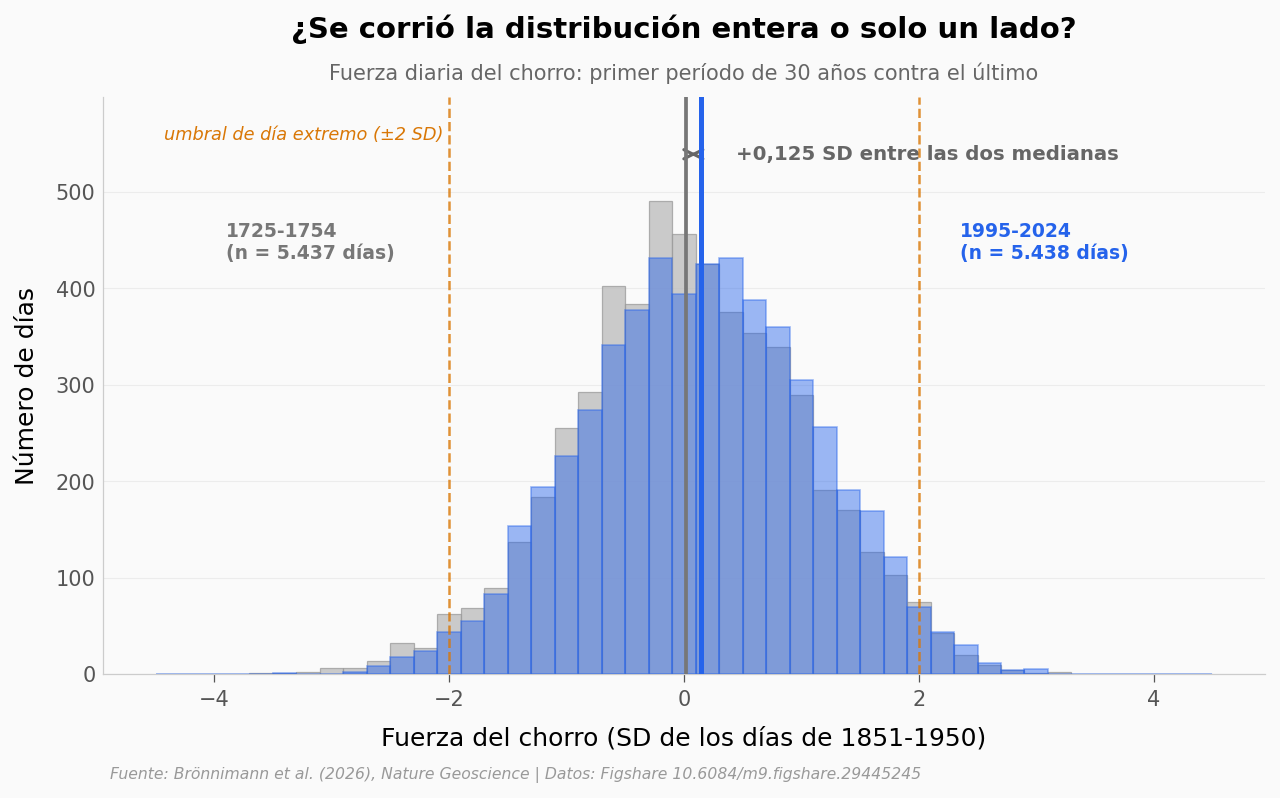

Cohen's d = 0.100  (efecto pequeño)
Mann-Whitney: U = 13.950.104, p = 3.60e-07
Dispersión día a día (SD): 0.971 en 1725-1754  vs  0.967 en 1995-2024
IQR 1725-1754: -0.609 a 0.711  (ancho 1.320)
IQR 1995-2024: -0.541 a 0.812  (ancho 1.353)

Días récord del registro completo:
  Más débil : 26/12/1836  (-4.19 SD)
  Más fuerte: 02/02/1761  (+4.06 SD)
  Desde 1836: 22/01/1993  (+3.62 SD)
  Desde 1836: 16/02/1962  (+3.51 SD)


In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

pre = diario.loc[diario.periodo == PERIODO_PREINDUSTRIAL, 'fuerza_sd']
act = diario.loc[diario.periodo == PERIODO_ACTUAL, 'fuerza_sd']

bins = np.linspace(-4.5, 4.5, 46)
n_pre, _, _ = ax.hist(pre, bins=bins, color=COLOR_CONTEXTO, alpha=0.75,
                      edgecolor='#999999', linewidth=0.6, zorder=3)
n_act, _, _ = ax.hist(act, bins=bins, color=COLOR_DATOS, alpha=0.45,
                      edgecolor=COLOR_DATOS, linewidth=0.8, zorder=4)

y_max = max(n_pre.max(), n_act.max()) * 1.22
ax.set_ylim(0, y_max)

m_pre, m_act = pre.median(), act.median()
ax.axvline(m_pre, color='#777777', linewidth=1.8, zorder=6)
ax.axvline(m_act, color=COLOR_DATOS, linewidth=2.4, zorder=6)
# La flecha va por encima de las barras: entre las dos medianas solo hay
# 0,125 SD y a la altura del pico quedaría del tamaño de un punto.
ax.annotate('', xy=(m_act, y_max * 0.90), xytext=(m_pre, y_max * 0.90),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text(m_act + 0.30, y_max * 0.90,
        f'{m_act - m_pre:+.3f} SD entre las dos medianas'.replace('.', ','),
        fontsize=9.5, fontweight='bold', color='#666666', ha='left', va='center')

ax.axvline(-2, color=COLOR_REFERENCIA, linewidth=1.2, linestyle='--', alpha=0.8, zorder=5)
ax.axvline(2, color=COLOR_REFERENCIA, linewidth=1.2, linestyle='--', alpha=0.8, zorder=5)
ax.text(-2.05, y_max * 0.95, 'umbral de día extremo (±2 SD)', fontsize=8.5,
        color=COLOR_REFERENCIA, ha='right', va='top', style='italic')

ax.text(-3.9, y_max * 0.72, f'{PERIODO_PREINDUSTRIAL}\n(n = 5.437 días)', fontsize=9,
        color='#777777', fontweight='bold')
ax.text(2.35, y_max * 0.72, f'{PERIODO_ACTUAL}\n(n = 5.438 días)', fontsize=9,
        color=COLOR_DATOS, fontweight='bold')

ax.set_title('¿Se corrió la distribución entera o solo un lado?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Fuerza diaria del chorro: primer período de 30 años contra el último',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Fuerza del chorro (SD de los días de 1851-1950)')
ax.set_ylabel('Número de días')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_anomalia.png', dpi=200, bbox_inches='tight')
plt.show()

# Tamaño del efecto y dispersión
s_pool = np.sqrt(((len(pre) - 1) * pre.var(ddof=1) + (len(act) - 1) * act.var(ddof=1))
                 / (len(pre) + len(act) - 2))
d = (act.mean() - pre.mean()) / s_pool
u, p = stats.mannwhitneyu(pre, act)
q1_pre, q3_pre = pre.quantile([0.25, 0.75])
q1_act, q3_act = act.quantile([0.25, 0.75])

print(f"Cohen's d = {d:.3f}  (efecto pequeño)")
print(f'Mann-Whitney: U = ' + f'{u:,.0f}'.replace(',', '.') + f', p = {p:.2e}')
print(f'Dispersión día a día (SD): {pre.std(ddof=1):.3f} en {PERIODO_PREINDUSTRIAL}'
      f'  vs  {act.std(ddof=1):.3f} en {PERIODO_ACTUAL}')
print(f'IQR {PERIODO_PREINDUSTRIAL}: {q1_pre:.3f} a {q3_pre:.3f}  (ancho {q3_pre - q1_pre:.3f})')
print(f'IQR {PERIODO_ACTUAL}: {q1_act:.3f} a {q3_act:.3f}  (ancho {q3_act - q1_act:.3f})')
print()
print('Días récord del registro completo:')
extremo_min = diario.loc[diario.fuerza_sd.idxmin()]
extremo_max = diario.loc[diario.fuerza_sd.idxmax()]
desde_1836 = diario[diario.anio > 1836].nlargest(2, 'fuerza_sd')
print(f'  Más débil : {int(extremo_min.dia):02d}/{int(extremo_min.mes):02d}/'
      f'{int(extremo_min.anio)}  ({extremo_min.fuerza_sd:+.2f} SD)')
print(f'  Más fuerte: {int(extremo_max.dia):02d}/{int(extremo_max.mes):02d}/'
      f'{int(extremo_max.anio)}  ({extremo_max.fuerza_sd:+.2f} SD)')
for _, fila in desde_1836.iterrows():
    print(f'  Desde 1836: {int(fila.dia):02d}/{int(fila.mes):02d}/{int(fila.anio)}'
          f'  ({fila.fuerza_sd:+.2f} SD)')

## La forma, no el tamaño

Las dos campanas casi se calcan. La dispersión día a día apenas se mueve —**0,971 SD** en 1725-1754 contra **0,967 SD** en 1995-2024—, así que el chorro no se volvió más errático. Y el rango intercuartílico del período actual va de **-0,541 a +0,812 SD**: una distribución ancha, casi simétrica. Nada de "la mayoría de los días rondan tal valor".

Lo que cambió es el reparto entre las colas. La izquierda se adelgazó: los días de chorro parado bajaron de **2,00%** a **1,27%**, el mínimo de los diez períodos. La derecha se movió, pero mucho menos: los días de chorro muy fuerte subieron de **1,97%** a **2,24%** —un cuarto de punto contra los tres cuartos que perdió la cola débil— y hoy siguen por debajo del **2,41%** que tuvo 1965-1994.

Los dos récords del registro siguen siendo antiguos, y los dos aparecen en el paper. El 26 de diciembre de 1836 es el día más flojo de los 300 años (-4,19 SD) y nuestra reproducción lo devuelve exacto — el mejor control de que estamos leyendo la misma columna que ellos. El 22 de enero de 1993 (+3,62 SD) es el más fuerte desde entonces, y el 16 de febrero de 1962 (+3,51 SD) el segundo: esa fecha coincide con la marejada del Mar del Norte que inundó Hamburgo esa noche. La coincidencia la pone el registro histórico — estos índices marcan el día, no el vínculo.

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| La mediana de la fuerza del chorro subió +0,125 SD entre 1725-1754 y 1995-2024 | ✅ | El paper reporta 0,13 SD; nuestra reproducción da 0,125 (diferencia 4,2%). Métrica: mediana de los días de temporada fría, normalizada por la SD diaria de 1851-1950 |
| El percentil 2 subió más que la mediana (+0,162 vs +0,125 SD) | ✅ | El paper también lo reporta: *"the increase of the 2nd percentile is even stronger (0.16 standard deviations)"* |
| El percentil 98 apenas se movió (+0,048 SD) | ✅ | Calculado por nosotros sobre `distribucion_por_periodo.csv`. Es lo que sostiene la lectura de "creció por abajo, no por arriba" |
| Los días de chorro excepcionalmente débil son hoy los más raros del registro (1,27%) | ✅ | Mínimo de los diez períodos, contra 2,00% en 1725-1754. Umbral: -2 SD con la SD diaria de temporada fría 1851-1950 |
| No hay escalada en los días de chorro muy fuerte | ⚠️ | El último período (2,24%) queda por debajo de 1965-1994 (2,41%), pero por encima de 1725-1754 (1,97%). Y en ventanas de 60 años los últimos son el máximo del registro: 2,32% contra 2,12% de la mejor ventana anterior (1815-1874). El crecimiento de la cola fuerte es real, solo que tres veces menor que el adelgazamiento de la cola débil |
| El cambio es grande | ❌ | Cohen's d = 0,10 entre el primer y el último período: efecto **pequeño**. Con 10.875 días, Mann-Whitney da p < 0,0001 — significativo no es sinónimo de grande |
| El chorro se desplazó hacia el polo | ⚠️ | Débil en nuestra reproducción. La mediana de latitud sube apenas +0,011 SD del primer al último período. El último (+0,066 SD) es el más alto de los diez, pero 1725-1754 (+0,055) queda casi igual, la tendencia sobre los diez períodos no es significativa (p = 0,37) y el contraste día a día entre los dos períodos da Cohen's d = 0,01 con Mann-Whitney p = 0,63 (n = 5.437 vs 5.438): sin efecto detectable en esta mitad de los datos |
| Los índices explican hasta un 40% de la variabilidad diaria de temperatura en Europa occidental | ⚠️ | Es un resultado del paper, no de este notebook: requiere campos de temperatura en rejilla que no están en el depósito. El cuerpo del artículo lo precisa como *"in some locations, up to 40%"* |
| El chorro será menos extremo en el futuro | ⚠️ | El *"less extreme"* del título descansa en buena parte sobre proyecciones CMIP6 hasta 2100 que **no reproducimos**. El paper lo enmarca como una posible reducción (*"suggesting a potential reduction"*), no como un hecho |

> **Limitaciones**
>
> - **Es la huella en superficie, no el chorro.** Los índices salen de gradientes de presión entre cuatro estaciones, no de una medición del viento en altura. El paper lo advierte: *"our diagnostics describe the surface imprint"*.
> - **Reproducimos 1 de los 3 datasets del depósito.** Las simulaciones (`ModE-Sim_daily_pressure_series.zip`, 180,1 MB) y los índices de modelo (`Jet_Indices.zip`, 386,0 MB) exceden el límite de 50 MB de este Lab. Toda la mitad de modelado y proyección del paper queda fuera.
> - **El archivo de Figshare arranca en 1706, el análisis publicado en 1725.** Usamos 1725-2024 para coincidir con el paper; los 19 años previos existen en el CSV original pero no entran aquí.
> - **El propio paper duda de su período de referencia.** Sobre el siglo XVIII: *"Strong excursions in the eighteenth century could point to remaining errors in the pressure measurements"*. Y ese siglo es justo la línea base de toda la comparación.
> - **Diseño observacional.** Esto es una reconstrucción, no un experimento: describe qué hizo el chorro, no por qué lo hizo. Ningún número de este notebook atribuye el cambio a una causa.

## Ahora tú

1. **¿La inclinación y la latitud cuentan la misma historia que la fuerza?** Los tres índices están cargados en `diario` como `inclinacion_sd` y `latitud_sd`. Repite el análisis de percentiles cambiando `fuerza` por `latitud` en el bloque de la celda de percentiles — ¿también se mueve más el borde bajo que el alto?

2. **¿Qué pasa si mueves el umbral de "día extremo"?** `UMBRAL_EXTREMO` está en 2,0 SD. Prueba con 1,5 y con 2,5 sobre `diario` y mira si la caída de la cola débil en 1995-2024 sobrevive al cambio de umbral, o si es un artefacto de dónde pusimos la raya.

3. **¿Y si el chorro cambió de calendario en vez de cambiar de fuerza?** La columna `mes` te deja separar noviembre-diciembre de enero-febrero. ¿La subida de la mediana se reparte por igual entre los meses de la temporada fría, o se concentra en unos pocos?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿La subida se reparte por igual entre los meses de la temporada fría?
# Comparamos la mediana de cada mes en el primer período contra el último.

meses = {11: 'noviembre', 12: 'diciembre', 1: 'enero',
         2: 'febrero', 3: 'marzo', 4: 'abril'}

print('Mediana de la fuerza del chorro por mes (en SD de los días de 1851-1950)')
print(f'{"mes":<12}{PERIODO_PREINDUSTRIAL:>12}{PERIODO_ACTUAL:>12}{"cambio":>10}{"n días":>9}')
filas = []
for m, nombre in meses.items():
    a = diario[(diario.periodo == PERIODO_PREINDUSTRIAL) & (diario.mes == m)]['fuerza_sd']
    b = diario[(diario.periodo == PERIODO_ACTUAL) & (diario.mes == m)]['fuerza_sd']
    filas.append((nombre, a.median(), b.median(), b.median() - a.median(), len(b)))
    print(f'{nombre:<12}{a.median():>12.3f}{b.median():>12.3f}'
          f'{b.median() - a.median():>+10.3f}{len(b):>9}')

mayor = max(filas, key=lambda f: f[3])
menor = min(filas, key=lambda f: f[3])
print()
print(f'El mes que más sube es {mayor[0]} ({mayor[3]:+.3f} SD);'
      f' el que menos, {menor[0]} ({menor[3]:+.3f} SD).')
print('Ojo con leer demasiado en un solo mes: cada casilla tiene ~900 días,')
print('una sexta parte de los que sostienen la cifra del período completo.')

Mediana de la fuerza del chorro por mes (en SD de los días de 1851-1950)
mes            1725-1754   1995-2024    cambio   n días
noviembre          0.128       0.031    -0.097      900
diciembre          0.177       0.235    +0.058      930
enero             -0.053       0.208    +0.261      930
febrero            0.114       0.255    +0.141      848
marzo             -0.066       0.179    +0.245      930
abril             -0.108       0.028    +0.137      900

El mes que más sube es enero (+0.261 SD); el que menos, noviembre (-0.097 SD).
Ojo con leer demasiado en un solo mes: cada casilla tiene ~900 días,
una sexta parte de los que sostienen la cifra del período completo.


---

## Fuentes

**Paper**: [A strengthening yet less extreme Atlantic–European jet during winter](https://doi.org/10.1038/s41561-026-02069-z)  
*Nature Geoscience, 2026-09-10*

**Datos**: [Daily pressure series for European stations and derived daily indices of the strength, tilt, and latitude of the Atlantic-European jet](https://doi.org/10.6084/m9.figshare.29445245)  
*Figshare — índices diarios de fuerza, inclinación y latitud del chorro, 1725-2024*

**Referencias citadas**: [Material to Calculate Jet Indices (Code, Input Data and Output Data)](https://doi.org/10.6084/m9.figshare.28001564)

*20 afirmaciones verificadas contra estas fuentes*

---

*Notebook de [Ciencia a Mordiscos](https://cienciaamordiscos.com). Código y datos: [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab).*